# Artificial Bee Colony (ABC) Optimization Algorithm
### University Project Submission

**Course:** [Insert Course Name Here]
**Student Name:** [Insert Name Here]

---
## 1. Introduction
The Artificial Bee Colony (ABC) algorithm is a swarm intelligence algorithm inspired by the foraging behavior of honey bees. It divides the bee population into three types:
1. **Employed Bees:** Exploit known food sources (solutions) and share information with onlooker bees.
2. **Onlooker Bees:** Wait in the hive and choose a food source based on the information shared by employed bees (probability based on fitness).
3. **Scout Bees:** Randomly search the environment for new food sources when an existing one is abandoned (limit reached).

In this project, we implement the ABC algorithm to solve both **Minimization** and **Maximization** problems using a 4-variable objective function.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

## 2. Parameter Setup
Here we define the core parameters of our Artificial Bee Colony. These dictate how many agents we have, our search space, and the stopping condition.

In [2]:
# --- ABC Model Parameters ---
num_bees = 40                     # Total number of bees in the swarm
num_food_sources = num_bees // 2  # Half are employed, half are onlookers
limit = 50                        # Trials before a food source is abandoned
max_iterations = 100              # Stopping condition

# --- Problem Dimensions and Bounds ---
dimensions = 4                    # 4 decision variables (x1, x2, x3, x4)
lower_bound = -10.0
upper_bound = 10.0

## 3. Objective / Fitness Function Visualization
Before diving into the optimization, let's visualize our objective function in a 3D space. Since our problem has 4 variables, we will set $x_3 = 0$ and $x_4 = 0$ to plot a 3D surface of the first two dimensions ($x_1$ and $x_2$).

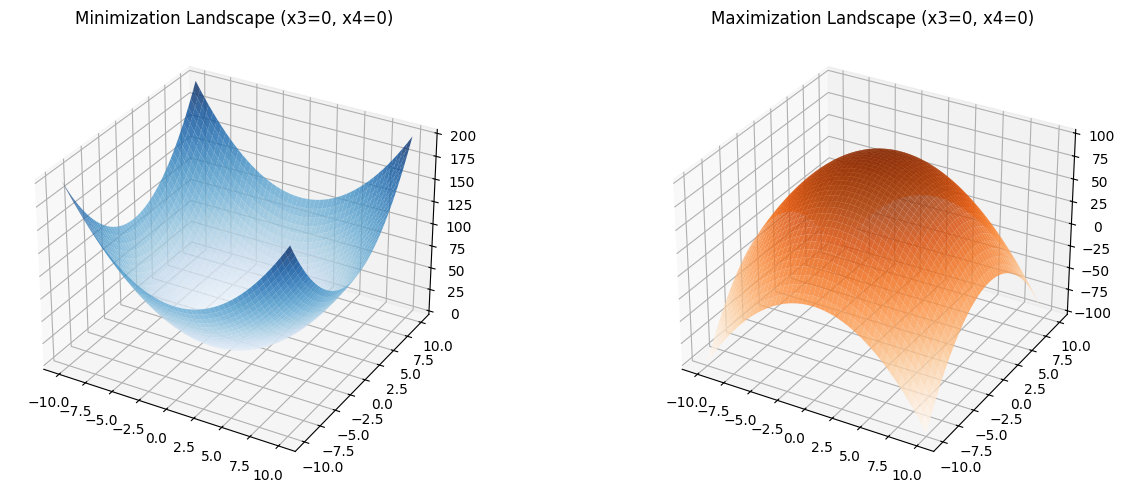

In [3]:
def plot_objective_space():
    x1 = np.linspace(-10, 10, 50)
    x2 = np.linspace(-10, 10, 50)
    X1, X2 = np.meshgrid(x1, x2)
    
    # Z_min: x1^2 + x2^2 + 0^2 + 0^2
    Z_min = X1**2 + X2**2
    
    # Z_max: 100 - (x1^2 + x2^2 + 0^2 + 0^2)
    Z_max = 100 - (X1**2 + X2**2)

    fig = plt.figure(figsize=(14, 5))
    
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(X1, X2, Z_min, cmap='Blues', alpha=0.8)
    ax1.set_title("Minimization Landscape (x3=0, x4=0)")
    
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(X1, X2, Z_max, cmap='Oranges', alpha=0.8)
    ax2.set_title("Maximization Landscape (x3=0, x4=0)")
    
    plt.tight_layout()
    plt.show()

plot_objective_space()

## 4. Helper Functions
To keep our implementation clean and modular, we define general functions for initializing food sources and modifying (mutating) them, along with boundary controls.

In [4]:
def initialize_population():
    """Phase 1: Initialization. Generates random food sources."""
    return [[random.uniform(lower_bound, upper_bound) for _ in range(dimensions)] 
            for _ in range(num_food_sources)]

def mutate_solution(current_solution, current_index, population):
    """Neighborhood search: slightly modifies a solution using a random partner."""
    # Pick a random partner that is not the current solution
    partner_index = random.choice([i for i in range(num_food_sources) if i != current_index])
    partner_solution = population[partner_index]
    
    # Choose one random dimension to modify
    j = random.randint(0, dimensions - 1)
    
    # Apply mutation formula: v_ij = x_ij + phi * (x_ij - x_kj)
    phi = random.uniform(-1, 1)
    new_solution = current_solution.copy()
    new_solution[j] = current_solution[j] + phi * (current_solution[j] - partner_solution[j])
    
    # Boundary Control
    new_solution[j] = max(lower_bound, min(upper_bound, new_solution[j]))
    return new_solution

## 5. Minimization Implementation
**Objective:** $f(x_1, x_2, x_3, x_4) = x_1^2 + x_2^2 + x_3^2 + x_4^2$
The minimum possible value is **0**, achieved at $x = (0,0,0,0)$.

In [5]:
def objective_min(x):
    return sum(xi**2 for xi in x)

def fitness_min(obj_val):
    """For minimization: lower objective value = higher fitness."""
    return 1.0 / (1.0 + obj_val) if obj_val >= 0 else 1.0 + abs(obj_val)

# --- Initialization Phase ---
pop_min = initialize_population()
fit_min = [fitness_min(objective_min(sol)) for sol in pop_min]
trials_min = [0] * num_food_sources

global_best_sol_min = None
global_best_obj_min = float('inf')
convergence_min = []

print("=== Starting Minimization Problem ===\n")

for it in range(max_iterations):
    # --- Employed Bee Phase ---
    for i in range(num_food_sources):
        new_sol = mutate_solution(pop_min[i], i, pop_min)
        new_obj = objective_min(new_sol)
        new_fit = fitness_min(new_obj)
        
        if new_fit > fit_min[i]:
            pop_min[i] = new_sol
            fit_min[i] = new_fit
            trials_min[i] = 0
        else:
            trials_min[i] += 1
            
    # --- Probability Calculation ---
    total_fit = sum(fit_min)
    probabilities = [f / total_fit for f in fit_min]
    
    # --- Onlooker Bee Phase ---
    t, i = 0, 0
    while t < num_food_sources:
        if random.random() < probabilities[i]:
            t += 1
            new_sol = mutate_solution(pop_min[i], i, pop_min)
            new_obj = objective_min(new_sol)
            new_fit = fitness_min(new_obj)
            
            if new_fit > fit_min[i]:
                pop_min[i] = new_sol
                fit_min[i] = new_fit
                trials_min[i] = 0
            else:
                trials_min[i] += 1
        i = (i + 1) % num_food_sources
        
    # --- Scout Bee Phase ---
    for i in range(num_food_sources):
        if trials_min[i] >= limit:
            pop_min[i] = [random.uniform(lower_bound, upper_bound) for _ in range(dimensions)]
            fit_min[i] = fitness_min(objective_min(pop_min[i]))
            trials_min[i] = 0
            
    # --- Global Best Update ---
    for i in range(num_food_sources):
        obj_val = objective_min(pop_min[i])
        if obj_val < global_best_obj_min:
            global_best_obj_min = obj_val
            global_best_sol_min = pop_min[i].copy()
            
    convergence_min.append(global_best_obj_min)
    
    # Print Every Iteration
    formatted_sol = [round(x, 4) for x in global_best_sol_min]
    print(f"Iteration {it + 1:3d} | Best Obj: {global_best_obj_min:10.6f} | Solution: {formatted_sol}")

=== Starting Minimization Problem ===

Iteration   1 | Best Obj:  12.808124 | Solution: [-0.1485, 0.2231, -3.1527, 1.6723]
Iteration   2 | Best Obj:   3.341770 | Solution: [-0.1485, 0.2231, 0.688, 1.6723]
Iteration   3 | Best Obj:   0.733196 | Solution: [0.0045, 0.2231, 0.688, 0.4583]
Iteration   4 | Best Obj:   0.703768 | Solution: [0.0045, 0.1427, 0.688, 0.4583]
Iteration   5 | Best Obj:   0.519910 | Solution: [0.0045, 0.083, 0.688, 0.1991]
Iteration   6 | Best Obj:   0.318567 | Solution: [-0.1588, 0.0035, -0.495, 0.2198]
Iteration   7 | Best Obj:   0.318567 | Solution: [-0.1588, 0.0035, -0.495, 0.2198]
Iteration   8 | Best Obj:   0.078844 | Solution: [0.0045, 0.083, 0.191, 0.1883]
Iteration   9 | Best Obj:   0.055440 | Solution: [0.0045, 0.083, 0.191, 0.1097]
Iteration  10 | Best Obj:   0.055435 | Solution: [0.004, 0.083, 0.191, 0.1097]
Iteration  11 | Best Obj:   0.040633 | Solution: [-0.1588, 0.0035, -0.0717, -0.1012]
Iteration  12 | Best Obj:   0.032308 | Solution: [-0.1398, 0.00

## 6. Maximization Implementation
**Objective:** $f(x_1, x_2, x_3, x_4) = 100 - (x_1^2 + x_2^2 + x_3^2 + x_4^2)$
The maximum possible value is **100**, achieved at $x = (0,0,0,0)$.

In [6]:
def objective_max(x):
    return 100.0 - sum(xi**2 for xi in x)

def fitness_max(obj_val):
    """For maximization: higher objective value = higher fitness."""
    return 1.0 + obj_val if obj_val >= 0 else 1.0 / (1.0 + abs(obj_val))

# --- Initialization Phase ---
pop_max = initialize_population()
fit_max = [fitness_max(objective_max(sol)) for sol in pop_max]
trials_max = [0] * num_food_sources

global_best_sol_max = None
global_best_obj_max = float('-inf')
convergence_max = []

print("=== Starting Maximization Problem ===\n")

for it in range(max_iterations):
    # --- Employed Bee Phase ---
    for i in range(num_food_sources):
        new_sol = mutate_solution(pop_max[i], i, pop_max)
        new_obj = objective_max(new_sol)
        new_fit = fitness_max(new_obj)
        
        if new_fit > fit_max[i]:
            pop_max[i] = new_sol
            fit_max[i] = new_fit
            trials_max[i] = 0
        else:
            trials_max[i] += 1
            
    # --- Probability Calculation ---
    total_fit = sum(fit_max)
    probabilities = [f / total_fit for f in fit_max]
    
    # --- Onlooker Bee Phase ---
    t, i = 0, 0
    while t < num_food_sources:
        if random.random() < probabilities[i]:
            t += 1
            new_sol = mutate_solution(pop_max[i], i, pop_max)
            new_obj = objective_max(new_sol)
            new_fit = fitness_max(new_obj)
            
            if new_fit > fit_max[i]:
                pop_max[i] = new_sol
                fit_max[i] = new_fit
                trials_max[i] = 0
            else:
                trials_max[i] += 1
        i = (i + 1) % num_food_sources
        
    # --- Scout Bee Phase ---
    for i in range(num_food_sources):
        if trials_max[i] >= limit:
            pop_max[i] = [random.uniform(lower_bound, upper_bound) for _ in range(dimensions)]
            fit_max[i] = fitness_max(objective_max(pop_max[i]))
            trials_max[i] = 0
            
    # --- Global Best Update ---
    for i in range(num_food_sources):
        obj_val = objective_max(pop_max[i])
        if obj_val > global_best_obj_max:
            global_best_obj_max = obj_val
            global_best_sol_max = pop_max[i].copy()
            
    convergence_max.append(global_best_obj_max)
    
    # Print Every Iteration
    formatted_sol = [round(x, 4) for x in global_best_sol_max]
    print(f"Iteration {it + 1:3d} | Best Obj: {global_best_obj_max:10.6f} | Solution: {formatted_sol}")

=== Starting Maximization Problem ===

Iteration   1 | Best Obj:  95.846922 | Solution: [-1.1691, -1.5097, -0.6872, -0.1873]
Iteration   2 | Best Obj:  97.164112 | Solution: [0.2226, -1.5097, -0.6872, -0.1873]
Iteration   3 | Best Obj:  99.286596 | Solution: [-0.0099, 0.1639, 0.7338, 0.3848]
Iteration   4 | Best Obj:  99.502771 | Solution: [-0.1874, 0.3369, 0.1126, 0.5796]
Iteration   5 | Best Obj:  99.512880 | Solution: [-0.1874, 0.3369, 0.0508, 0.5796]
Iteration   6 | Best Obj:  99.580266 | Solution: [-0.1874, 0.2148, 0.0508, 0.5796]
Iteration   7 | Best Obj:  99.858650 | Solution: [0.2226, -0.1613, 0.1752, -0.1873]
Iteration   8 | Best Obj:  99.925729 | Solution: [-0.2457, -0.0814, 0.0732, 0.0437]
Iteration   9 | Best Obj:  99.927403 | Solution: [-0.2457, -0.0814, 0.0732, 0.0153]
Iteration  10 | Best Obj:  99.935901 | Solution: [-0.0284, -0.1613, 0.1751, -0.0814]
Iteration  11 | Best Obj:  99.936626 | Solution: [0.0089, -0.1613, 0.1751, -0.0814]
Iteration  12 | Best Obj:  99.992229 

## 7. Result Comparison & Convergence Curves
Let's compare the performance of the ABC algorithm on both problems.

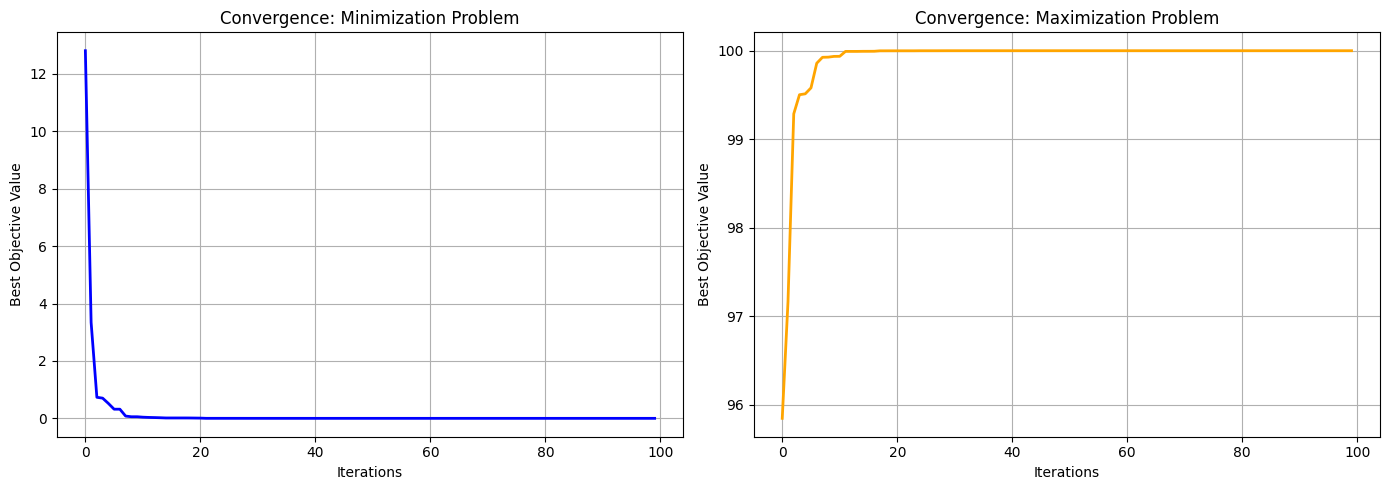

FINAL COMPARISON SUMMARY
MINIMIZATION PROBLEM:
Target Value : 0.000000
Achieved Obj : 0.000000
Best Solution: [-0.0, -0.0, -0.0, -0.0]
--------------------------------------------------
MAXIMIZATION PROBLEM:
Target Value : 100.000000
Achieved Obj : 100.000000
Best Solution: [0.0, 0.0, 0.0, 0.0]


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(convergence_min, color='blue', linewidth=2)
ax1.set_title("Convergence: Minimization Problem")
ax1.set_xlabel("Iterations")
ax1.set_ylabel("Best Objective Value")
ax1.grid(True)

ax2.plot(convergence_max, color='orange', linewidth=2)
ax2.set_title("Convergence: Maximization Problem")
ax2.set_xlabel("Iterations")
ax2.set_ylabel("Best Objective Value")
ax2.grid(True)

plt.tight_layout()
plt.show()

print("=" * 50)
print("FINAL COMPARISON SUMMARY")
print("=" * 50)
print("MINIMIZATION PROBLEM:")
print(f"Target Value : 0.000000")
print(f"Achieved Obj : {global_best_obj_min:.6f}")
print(f"Best Solution: {[round(x, 4) for x in global_best_sol_min]}")
print("-" * 50)
print("MAXIMIZATION PROBLEM:")
print(f"Target Value : 100.000000")
print(f"Achieved Obj : {global_best_obj_max:.6f}")
print(f"Best Solution: {[round(x, 4) for x in global_best_sol_max]}")
print("=" * 50)

## 8. NetLogo Simulation Guidance
As part of the project requirements, here is an explanation of how to map this algorithmic logic into a visual **NetLogo** simulation.

### The Environment (Patches)
- The NetLogo 2D grid represents our Search Space. You can use the X and Y coordinates of patches to represent 2 of our decision variables ($x_1$ and $x_2$), and store the other variables ($x_3, x_4$) as properties within the turtle agents.
- Color the patches according to fitness (e.g., green for high fitness areas, red for low fitness) to visually represent the landscape.

### Agent Breeds (Turtles)
In NetLogo, you create `breeds` for different agents. The ABC logic maps perfectly:

1. **`breed [employed-bees employed-bee]`**
   - **Role:** They stay stationed at specific "food source" patches.
   - **Action:** At every tick, they execute the neighborhood search. They pick another random employed bee, look at their patch coordinates, calculate a mutation $v_i = x_i + \phi(x_i - x_k)$, and test that new patch. If it's better, they move there. Otherwise, they increment their internal `trial_counter`.

2. **`breed [onlooker-bees onlooker-bee]`**
   - **Role:** They wait in the center "hive".
   - **Action:** Employed bees broadcast their fitness values globally. The onlookers use a roulette-wheel selection (`rnd` extension) to pick a food source. They then fly to that employed bee's patch and perform the same neighborhood search.

3. **`breed [scout-bees scout-bee]`**
   - **Role:** The explorers that prevent the swarm from getting stuck in local optima.
   - **Action:** When an employed bee's `trial_counter` hits the `limit` parameter, it changes its breed to `scout-bee`. It immediately jumps to a completely random patch on the grid, evaluates it, sets its `trial_counter` to 0, and changes back to an `employed-bee`.

This separation of roles makes ABC highly effective and visually striking when implemented in a multi-agent environment like NetLogo.